# GeoJSON CBD Treatment Difference-in-Differences

This notebook uses the GeoJSON-derived CBD route treatment panel created by `src/build_geojson_cbd_treatment.py`.

Main analysis file: `../data/processed/nyc_did_panel_geojson_intersection.csv`

Treatment definition: a route is treated if any retained route shape intersects the CBD geofence. 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL_PATH = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
POLICY_MONTH = pd.Timestamp("2025-01-01")

plt.style.use("seaborn-v0_8-whitegrid")

## Load and Prepare the Panel

The panel is already restricted to non-Staten-Island NYC bus-speed rows and the balanced analysis window. We add a simple DiD interaction, `did = cbd_route * post`.

In [2]:
df = pd.read_csv(PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df["month_str"] = df["month"].dt.to_period("M").astype(str)
df["treated"] = df["cbd_route"].astype(int)
df["post_int"] = df["post"].astype(int)
df["did"] = df["treated"] * df["post_int"]

print(f"Rows: {len(df):,}")
print(f"Routes: {df['route_id'].nunique():,}")
print(f"Months: {df['month'].nunique():,}")
print(f"Window: {df['month'].min().date()} to {df['month'].max().date()}")
print(f"Treated routes: {df.loc[df['cbd_route'], 'route_id'].nunique():,}")
print(f"Control routes: {df.loc[~df['cbd_route'], 'route_id'].nunique():,}")
df.head()

Rows: 36,077
Routes: 305
Months: 34
Window: 2023-08-01 to 2026-05-01
Treated routes: 88
Control routes: 217


,month,borough,day_type,trip_type,route_id,period,total_operating_time,total_mileage,average_speed,cbd_route,...,any_shape_within_cbd,any_high_share_shape_in_cbd,max_share_length_in_cbd,total_share_length_in_cbd,number_of_shapes,post,month_str,treated,post_int,did
0,2023-08-01,Bronx,1,LCL/LTD,BX1,Off-Peak,"3,279.32305514812","22,748.42680835724",6.936928,False,...,False,False,0.0,0.0,163,False,2023-08,0,0,0
1,2023-08-01,Bronx,1,LCL/LTD,BX1,Peak,"1,450.57583022118","9,865.05801200867",6.800788,False,...,False,False,0.0,0.0,163,False,2023-08,0,0,0
2,2023-08-01,Bronx,2,LCL/LTD,BX1,Off-Peak,782.3700017333,"5,189.1539182663",6.632608,False,...,False,False,0.0,0.0,163,False,2023-08,0,0,0
3,2023-08-01,Bronx,2,LCL/LTD,BX1,Peak,281.94777727127,"1,897.10996437073",6.728586,False,...,False,False,0.0,0.0,163,False,2023-08,0,0,0
4,2023-08-01,Bronx,1,LCL/LTD,BX10,Off-Peak,"2,853.04695209861","25,382.59106588364",8.896661,False,...,False,False,0.0,0.0,250,False,2023-08,0,0,0


## Short EDA

First, inspect what observations are in the clean panel: treatment balance, borough coverage, service period coverage, and simple pre/post means. These are descriptive, not causal estimates.

In [3]:
summary = pd.Series({
    "rows": len(df),
    "routes": df["route_id"].nunique(),
    "months": df["month"].nunique(),
    "treated_routes": df.loc[df["cbd_route"], "route_id"].nunique(),
    "control_routes": df.loc[~df["cbd_route"], "route_id"].nunique(),
    "pre_months": df.loc[df["month"] < POLICY_MONTH, "month"].nunique(),
    "post_months": df.loc[df["month"] >= POLICY_MONTH, "month"].nunique(),
})
summary

rows              36077
routes              305
months               34
treated_routes       88
control_routes      217
pre_months           17
post_months          17
dtype: int64

In [4]:
pd.crosstab(df["borough"], df["cbd_route"], margins=True)

cbd_route,False,True,All
borough,,,
Bronx,6206,1436,7642
Brooklyn,7626,1240,8866
Manhattan,1572,4080,5652
Queens,10963,2954,13917
All,26367,9710,36077


In [5]:
prepost_means = (
    df.groupby(["cbd_route", "post"], observed=True)["average_speed"]
    .agg(["mean", "count"])
    .reset_index()
)
prepost_means

,cbd_route,post,mean,count
0,False,False,7.994466,12888
1,False,True,8.089769,13479
2,True,False,9.400474,4850
3,True,True,9.599074,4860


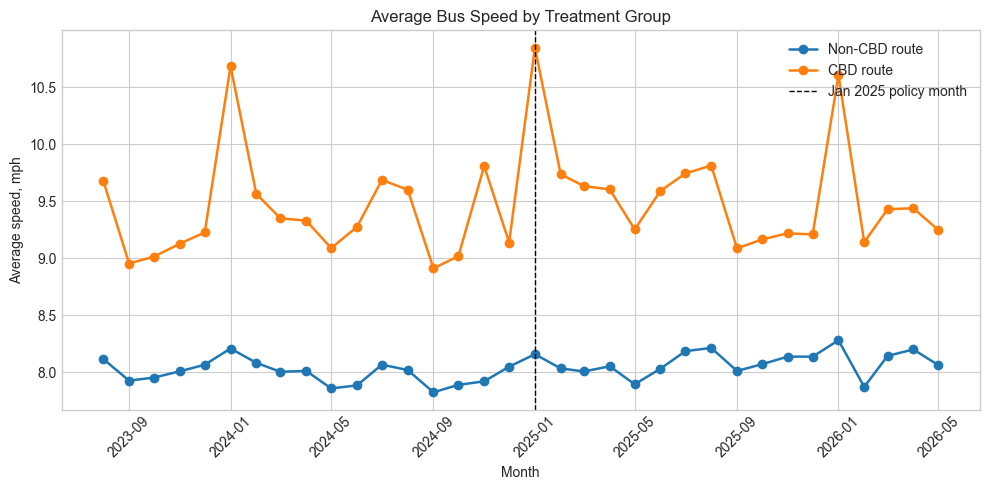

In [6]:
trend = (
    df.groupby(["month", "cbd_route"], observed=True)["average_speed"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for treated_value, group in trend.groupby("cbd_route"):
    label = "CBD route" if treated_value else "Non-CBD route"
    ax.plot(group["month"], group["average_speed"], marker="o", linewidth=1.8, label=label)
ax.axvline(POLICY_MONTH, color="black", linestyle="--", linewidth=1, label="Jan 2025 policy month")
ax.set_title("Average Bus Speed by Treatment Group")
ax.set_xlabel("Month")
ax.set_ylabel("Average speed, mph")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

## Difference-in-Differences

Main specification:

`average_speed ~ cbd_route * post + route fixed effects + month fixed effects + period fixed effects`

Because route fixed effects absorb the time-invariant treatment indicator and month fixed effects absorb the post indicator, the estimated coefficient of interest is `did`. Standard errors are clustered by route. The primary sample is weekday rows (`day_type == 1`).

In [7]:
def run_did(data, label):
    model = smf.ols(
        "average_speed ~ did + C(route_id) + C(month_str) + C(period)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["route_id"]})
    ci = model.conf_int().loc["did"]
    return {
        "sample": label,
        "rows": int(model.nobs),
        "routes": data["route_id"].nunique(),
        "estimate_mph": model.params["did"],
        "std_error": model.bse["did"],
        "p_value": model.pvalues["did"],
        "ci_low": ci.iloc[0],
        "ci_high": ci.iloc[1],
    }

results = pd.DataFrame([
    run_did(df.query("day_type == 1").copy(), "Weekday, all periods"),
    run_did(df.copy(), "All day types, all periods"),
    run_did(df.query("day_type == 1 and period == 'Peak'").copy(), "Weekday peak"),
    run_did(df.query("day_type == 1 and period == 'Off-Peak'").copy(), "Weekday off-peak"),
])

results

,sample,rows,routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,"Weekday, all periods",19108,301,0.156415,0.047743,0.001052,0.062840,0.249990
1,"All day types, all periods",36077,305,0.144994,0.044376,0.001085,0.058018,0.231969
2,Weekday peak,9526,296,0.186601,0.046222,0.000054,0.096007,0.277195
3,Weekday off-peak,9582,301,0.130337,0.054364,0.016508,0.023786,0.236887


Verified run from the current processed panel:

- Weekday main estimate: about `+0.156 mph`, clustered SE about `0.048`, p-value about `0.001`.
- All-days estimate: about `+0.145 mph`, clustered SE about `0.044`, p-value about `0.001`.
- Weekday peak estimate: about `+0.187 mph`.
- Weekday off-peak estimate: about `+0.130 mph`.

Interpretation: under the broad GeoJSON CBD-intersection treatment definition, treated routes saw a modest relative increase in average speeds after January 2025 compared with non-CBD routes, conditional on route, month, and period fixed effects.

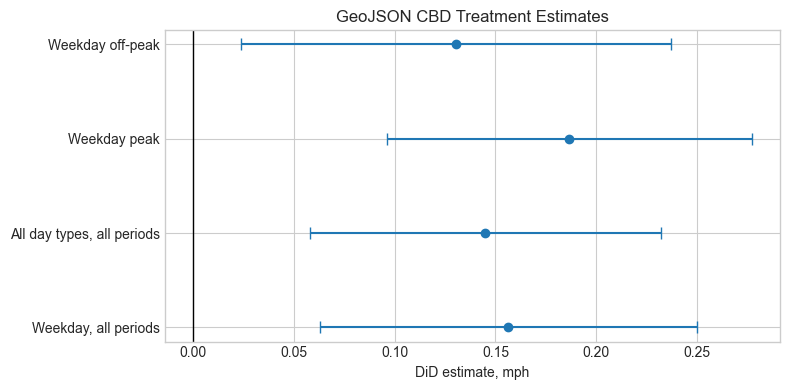

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_results = results.set_index("sample")
ax.errorbar(
    plot_results["estimate_mph"],
    plot_results.index,
    xerr=[
        plot_results["estimate_mph"] - plot_results["ci_low"],
        plot_results["ci_high"] - plot_results["estimate_mph"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("DiD estimate, mph")
ax.set_title("GeoJSON CBD Treatment Estimates")
plt.tight_layout()

## Notes for Next Iteration

- The main treatment is intentionally broad: any CBD geofence intersection.
- The `max_share_length_in_cbd` and `total_share_length_in_cbd` fields can support later robustness checks with stricter treatment definitions.
- The current model is a clean two-way fixed-effects DiD. A useful next diagnostic would be an event-study plot to inspect pre-trends before treating the coefficient causally.